# Cube-to-Simplex Transformations: Reproducing Figures 5-7 and 12 of Pillards & Cools (2005)

Reproduces, using the QMCPy library [1], [2], the transformations behind `qmcpy.SimplexTransform`'s `origami`, `root`, and `shift` methods, matching Figures 5-7 of [3], plus its error-comparison figures (thesis Figs. 11-13; here we call it Figure 12 to match the thesis numbering) -- extended with Drop and, in a separate 3D comparison, Mirror, which the thesis itself omits from that experiment. The paper itself is paywalled; the figures reproduced here follow the equivalent, openly available presentation in Chapter 4 of the PhD thesis [4] that the paper condenses, since the two describe the same transformations and experiments.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/portfolio/simplex_transformations.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from qmcpy import SimplexTransform

rng = np.random.default_rng(7)

## A shared visualization: colored grids

Each transformation maps the unit cube $I_d$ onto the simplex $T_d = \{0 \le x_1 \le \cdots \le
x_d < 1\}$. To see *how* a transformation folds or stretches space, we lay a regular grid of
points over $I_d$, color each point by its original coordinates, transform the grid, and re-plot
with the *same* colors. Two points that end up close together but have very different colors
reveal a discontinuity (a "fold"); a smoothly-varying color field reveals a continuous map.

In [ ]:
def colored_grid_2d(n=24):
    lin = (np.arange(n) + 0.5) / n
    gx, gy = np.meshgrid(lin, lin)
    points = np.stack([gx.ravel(), gy.ravel()], axis=1)
    colors = np.stack([gx.ravel(), np.zeros_like(gx.ravel()), gy.ravel()], axis=1)  # RGB = (x1, 0, x2)
    return points, colors


def plot_panels(panels, colors, suptitle):
    """Each panel is (title, data) sharing `colors`, or (title, data, own_colors)
    for a transform like Drop that returns fewer points than it was given."""
    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4))
    for ax, panel in zip(axes, panels):
        title, data, *rest = panel
        panel_colors = rest[0] if rest else colors
        ax.scatter(data[:, 0], data[:, 1], c=panel_colors, s=18)
        ax.set_title(title)
        ax.set_xlabel('x1'); ax.set_ylabel('x2')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    fig.suptitle(suptitle)
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2)  # extra room so the x tick labels are never clipped
    plt.show()

## Figure 5: Transformation Origami

Origami recursively applies Sort within a grid of cubes, from a fine base-$b$ grid down to the
whole cube. `depth=0` has no finer scale above the base grid and is exactly Sort; each extra depth
adds one more finer level, matching the paper's Fig. 5 (thesis Fig. 4.5, $b=2$, $m=2$, $M=4$).
Compare `depth=0` (plain Sort) against `depth=1,2`: all three land on the same triangle, but the
color pattern inside it grows visibly more subdivided as depth increases -- each extra depth folds
in one more level of the grid without disturbing the coarser structure already in place.

We also show **Drop** and **Mirror** alongside it here (both are defined at $d=2$, unlike the
$d=5$ comparison in Figure 12 below): Drop keeps only the points already inside the triangle --
half the grid, since $1/2! = 1/2$ -- and simply discards the rest, visibly thinning the grid
without moving any point. Mirror keeps that same half fixed and reflects every other point through
the center $(0.5, 0.5)$; the color pattern shows this clearly as a hard seam along the diagonal,
in contrast to Sort/Origami's smoother (if still discontinuous) folding.

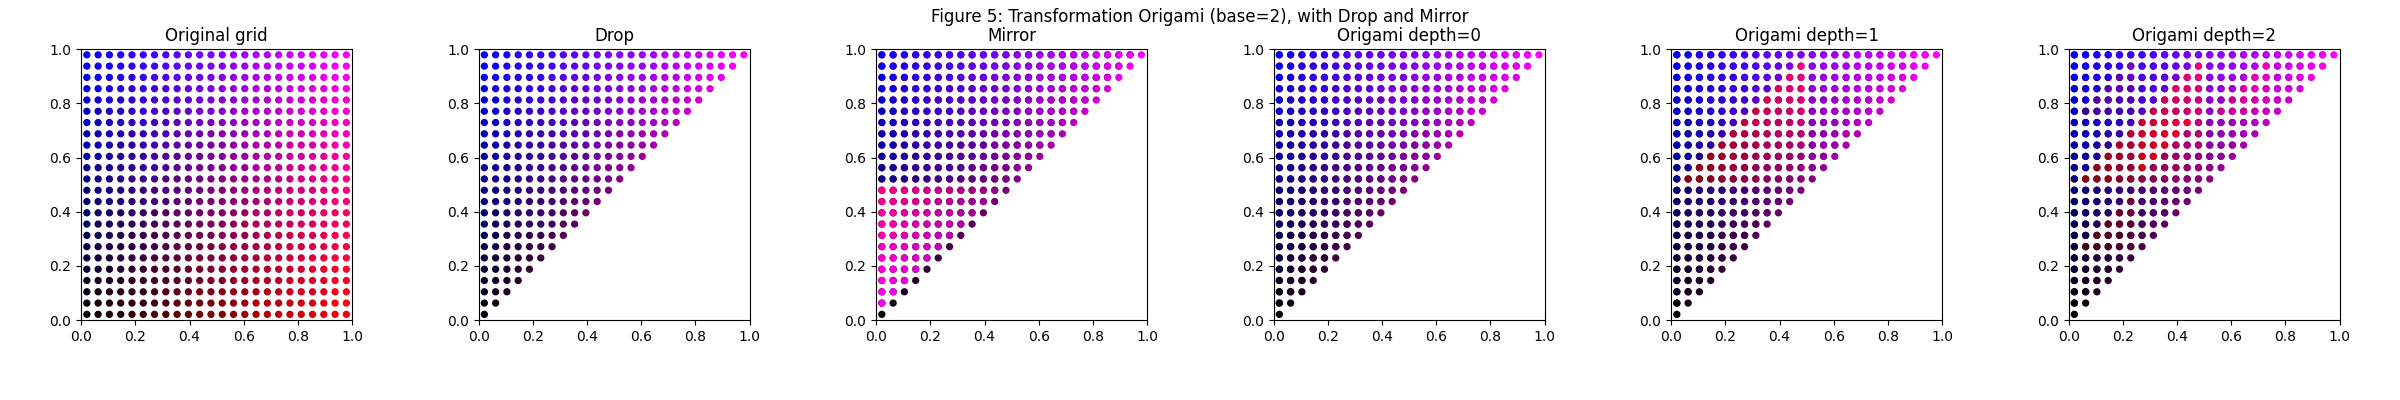

In [4]:
points, colors = colored_grid_2d(n=24)
transformer = SimplexTransform(dimension=2)

drop_mask = np.all(points[:, :-1] <= points[:, 1:], axis=1)
panels = [
    ("Original grid", points),
    ("Drop", transformer.drop(points), colors[drop_mask]),
    ("Mirror", transformer.mirror(points)),
]
for depth in (0, 1, 2):
    panels.append((f"Origami depth={depth}", transformer.origami(points, base=2, depth=depth)))

plot_panels(panels, colors, "Figure 5: Transformation Origami (base=2), with Drop and Mirror")

## Figure 6: Transformation Root (left) and Shift (right)

Root maps via the cumulative distribution function of the simplex; Shift pushes the cube into the
simplex $A_d = \{x : \sum_i x_i < 1\}$ and then re-maps $A_d$ onto $T_d$. The paper's Fig. 6
(thesis Fig. 4.6) shows both are continuous, but qualitatively different: Root is highly
non-uniform in the last coordinate (points near $x_d=0$ move far more than points near $x_d=1$),
while Shift keeps a visibly more uniform grid throughout. The color gradient below shows exactly
that: Root's bottom rows ($x_2$ near 0) compress into a thin sliver, while Shift's grid stays
close to regular top to bottom.

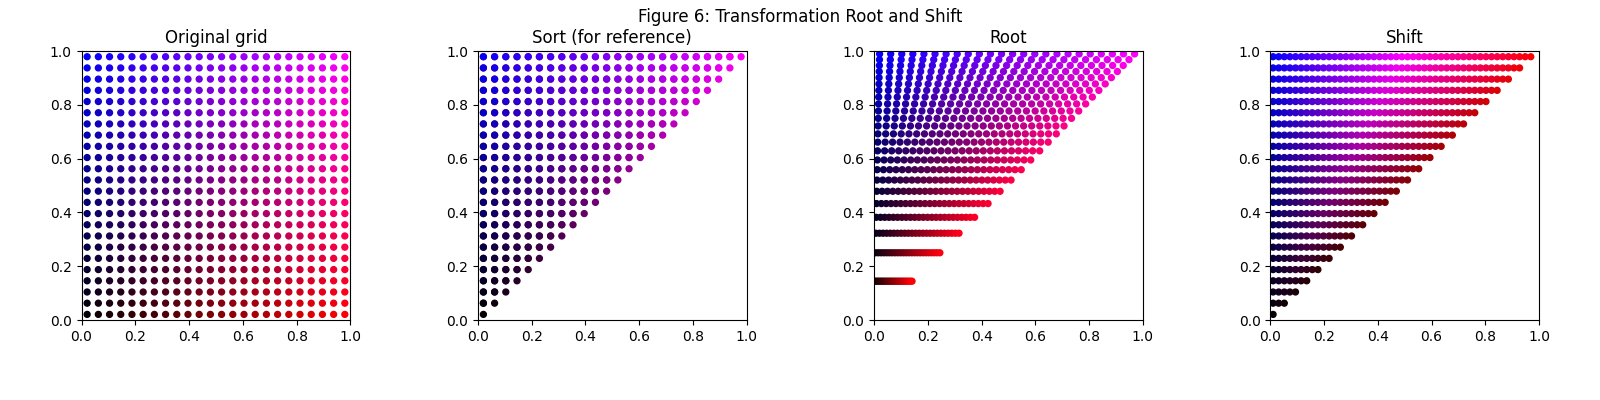

In [5]:
panels = [
    ("Original grid", points),
    ("Sort (for reference)", transformer.sort(points)),
    ("Root", transformer.root(points)),
    ("Shift", transformer.shift(points)),
]
plot_panels(panels, colors, "Figure 6: Transformation Root and Shift")

In [6]:
# The paper's own 2D worked example for Root (Sec. 4.3.5): a point near x2=0 is
# shifted far more than a point near x2=1.
near_0 = transformer.root(np.array([0.5, 0.01]))
near_1 = transformer.root(np.array([0.5, 0.99]))
print(f"root([0.5, 0.01]) = {near_0[0]}  (paper: [0.05, 0.1])")
print(f"root([0.5, 0.99]) = {np.round(near_1[0], 3)}  (paper: approx. [0.497, 0.995])")

root([0.5, 0.01]) = [0.05 0.1 ]  (paper: [0.05, 0.1])
root([0.5, 0.99]) = [0.497 0.995]  (paper: approx. [0.497, 0.995])


## Figure 7: Transformation Shift from $I_d$ to $A_d$, in three dimensions

Shift's first stage pushes the cube $I_d$ into $A_d = \{x \in I_d : \sum_i x_i < 1\}$: the
corner farthest from the origin ($(1,1,1)$) is pushed two-thirds of the way toward the origin, and
the three corners one step closer are each pushed halfway -- exactly the paper's Fig. 7
description. The second stage (a cumulative sum, `SimplexTransform`'s Eq. 4.6) then re-maps $A_d$
onto $T_d$. We expose that intermediate $A_d$ step here (it is internal to `shift`) to show both
stages of the picture.

In [7]:
def push_to_Ad(points):
    """The first stage of `SimplexTransform.shift`: I_d -> A_d, exposed here for illustration."""
    d = points.shape[1]
    order = np.argsort(points, axis=1)
    x = np.take_along_axis(points, order, axis=1)
    for j in range(d - 1):
        prev = x[:, j - 1] if j >= 1 else 0.0
        gap = x[:, j] - prev
        coeff = (d - j - 1) / (d - j)
        x[:, j:] -= (coeff * gap)[:, None]
    inverse_order = np.argsort(order, axis=1)
    return np.take_along_axis(x, inverse_order, axis=1)


# The paper's own corner check: (1,1,1) should land 2/3 of the way to the origin,
# i.e. at (1/3, 1/3, 1/3); (1,1,0)-type corners should land halfway, at (0.5, 0.5, 0).
corner_111 = push_to_Ad(np.array([[1.0, 1.0, 1.0]]))
corner_110 = push_to_Ad(np.array([[1.0, 1.0, 0.0]]))
print(f"push_to_Ad([1,1,1]) = {corner_111[0]}  (paper: [1/3, 1/3, 1/3] = {[round(1/3, 4)]*3})")
print(f"push_to_Ad([1,1,0]) = {corner_110[0]}  (paper: [0.5, 0.5, 0])")

push_to_Ad([1,1,1]) = [0.33333333 0.33333333 0.33333333]  (paper: [1/3, 1/3, 1/3] = [0.3333, 0.3333, 0.3333])
push_to_Ad([1,1,0]) = [0.5 0.5 0. ]  (paper: [0.5, 0.5, 0])


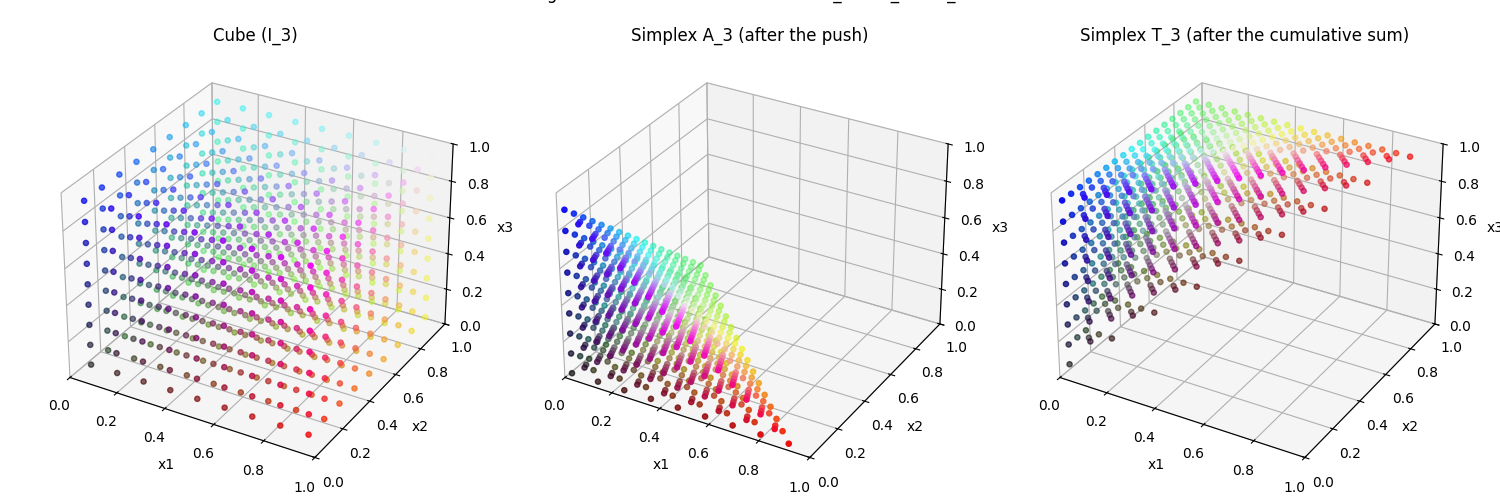

In [8]:
n = 9
lin = (np.arange(n) + 0.5) / n
gx, gy, gz = np.meshgrid(lin, lin, lin)
points_3d = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=1)
colors_3d = points_3d.copy()

a_points = push_to_Ad(points_3d)
t_points = np.cumsum(a_points, axis=1)  # Eq. 4.6: A_d -> T_d
assert np.allclose(t_points, SimplexTransform(dimension=3).shift(points_3d))

fig = plt.figure(figsize=(15, 5))
for i, (data, title) in enumerate([
    (points_3d, "Cube (I_3)"),
    (a_points, "Simplex A_3 (after the push)"),
    (t_points, "Simplex T_3 (after the cumulative sum)"),
]):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=colors_3d, s=14)
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
fig.suptitle("Figure 7: Transformation Shift from I_3 to A_3 to T_3", y=1.03)
plt.tight_layout()
plt.show()

## Visualizing the test functions

Figure 12 below measures integration error for four random test-function families used in the
thesis's own numerical experiments (Sec. 4.6). Before looking at that error comparison, it helps
to see what these functions actually look like. Since the real comparison uses $d=5$, we plot each
family here on the 2D simplex $T_2$ instead, using one illustrative, fixed draw of each family's
random parameters -- purely for visualization; Figure 12 draws its own fresh random parameters per
instance.

In [ ]:
def f1(x, beta):
    """Peak family: (sum_i |x_i - beta_i|) ** d, where d is x's own dimension."""
    return np.sum(np.abs(x - beta), axis=-1) ** x.shape[-1]


def f2(x, beta, radius_sq):
    """Discontinuous family: 1 if inside the ball of radius r around beta, else 0."""
    return (np.sum((x - beta) ** 2, axis=-1) < radius_sq).astype(float)


def f3(x, alpha, beta):
    """Smooth peak family: exp(-sum_i alpha_i |x_i - beta_i|)."""
    return np.exp(-np.sum(alpha * np.abs(x - beta), axis=-1))


def f4(x, alpha, beta):
    """Oscillatory family: cos(2*pi*beta + sum_i alpha_i x_i)."""
    return np.cos(2 * np.pi * beta + x @ alpha)


def sample_Td_grid(n=80):
    lin = (np.arange(n) + 0.5) / n
    gx, gy = np.meshgrid(lin, lin)
    pts = np.stack([gx.ravel(), gy.ravel()], axis=1)
    return pts[pts[:, 0] <= pts[:, 1]]


td_grid = sample_Td_grid()
vis_beta, vis_alpha, vis_radius_sq = np.array([0.3, 0.7]), np.array([0.6, 0.9]), 0.15

funcs_2d = {
    "$f_1$ (peak)": f1(td_grid, vis_beta),
    "$f_2$ (discontinuous)": f2(td_grid, vis_beta, vis_radius_sq),
    "$f_3$ (smooth peak)": f3(td_grid, vis_alpha, vis_beta),
    "$f_4$ (oscillatory)": f4(td_grid, vis_alpha, 0.2),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (title, vals) in zip(axes.ravel(), funcs_2d.items()):
    sc = ax.scatter(td_grid[:, 0], td_grid[:, 1], c=vals, s=10, cmap="viridis")
    fig.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.suptitle("The four test-function families, illustrated on $T_2$")
plt.tight_layout()
plt.show()

## Figure 12: Integration error vs. N, comparing all transformations

Sec. 4.6 of the thesis (Figs. 11-13 there; the paper condenses these into its own error-comparison
figures) integrates random test-function families over $T_d$ using each transformation, plotting
the average relative error against the number of QMC points $N$ on a log-log scale, in 5
dimensions, with $N$ ranging up to $10^7$ as in the paper. We reproduce four of its families:

- $f_1(\mathbf{x}) = \left(\sum_i |x_i - \beta_i|\right)^d$ (a peak function)
- $f_2(\mathbf{x}) = \mathbb{1}\left[\sum_i (x_i - \beta_i)^2 < r^2\right]$ (discontinuous)
- $f_3(\mathbf{x}) = \exp\left(-\sum_i \alpha_i |x_i - \beta_i|\right)$ (a smooth "peak" function)
- $f_4(\mathbf{x}) = \cos\left(2\pi\beta + \sum_i \alpha_i x_i\right)$ (oscillatory)

with $\alpha_i, \beta_i \sim U[0,1]$ (and a scalar $\beta$ for $f_4$) resampled for each of 8
random instances (the thesis uses 50; we use fewer, and a slightly coarser $N$ grid at the high
end, purely so this cell finishes in a reasonable time). Since $\int_{T_d} f$ has no convenient
closed form for random $\alpha,\beta$, we approximate it per instance with a very fine
(`N=2**20`) Sort-transformed Sobol' estimate and treat that as ground truth.

Two notes on $f_1$ and $f_2$: the paper states them in 2D with a literal "$d$" and "$d^2$" that we
read as the dimension itself; taken literally in 5D that makes $f_2$'s indicator true everywhere
(the largest possible squared distance inside $[0,1]^5$ is only $5$, well under $d^2=25$), so we
instead draw a random radius $r^2 \sim U[0.3, 1.0]$ per instance -- small enough to split points
both inside and outside the ball. $f_1$'s literal $d$-th power *is* well-defined in 5D (values stay
in roughly $[0, 5^5]$ on this domain) so we keep it as given.

We also add **Drop** to the comparison, which the thesis deliberately excludes: "we did not use
transformation Drop because this transformation loses too many points in high dimensions." In 5D,
Drop keeps only $1/5! = 1/120$ of its input points, so at small $N$ it can retain *zero* points for
every one of the 8 random instances -- those $N$ are simply omitted from Drop's curve below, which
is itself a direct demonstration of the thesis's stated reason for leaving it out. We leave out
Mirror here for the same reason the thesis does: it has no closed form for $d>3$ (this project's
`SimplexTransform.mirror` only supports $d \le 3$) -- but we do add both Drop and Mirror to the 2D
Figure 5 comparison above.

The thesis's own conclusion for the four transformations it does compare: "there is not much
difference in performance between the transformations except for transformation Shift, which
performs somewhat worse than the others... probably because transformation Shift is actually a
transformation from the unit cube to $A_d$ and not to $T_d$." Our reproduction below shows exactly
that, and further shows Drop trailing well behind all of them once it has enough points to produce
an estimate at all -- and $f_2$'s discontinuity visibly slowing every transformation's convergence
rate, regardless of which one is used.

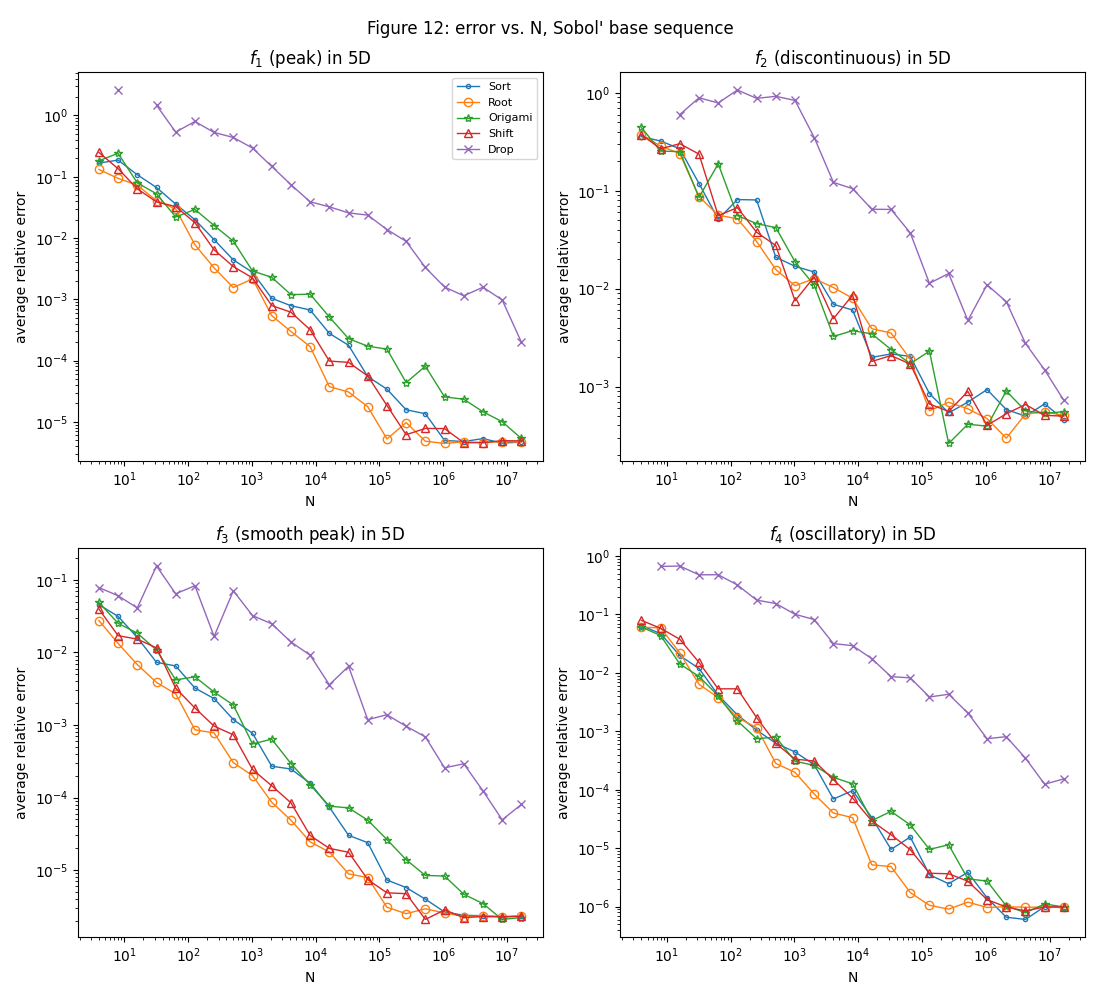

In [10]:
import math
from qmcpy import Sobol

d = 5
n_funcs = 8
ns = [2 ** k for k in range(2, 25)]  # up to ~1.7e7, matching the paper's N range up to 10^7
ref_n = 2 ** 16 if IN_COLAB else 2 ** 20  # smaller reference estimate to avoid a Colab timeout
vol_Td = 1.0 / math.factorial(d)


def fresh_seed():
    return int(rng.integers(1_000_000_000))


transformer_5d = SimplexTransform(dimension=d)
error_transforms = {
    "Sort": transformer_5d.sort,
    "Root": transformer_5d.root,
    "Origami": lambda pts: transformer_5d.origami(pts, base=2, depth=3),
    "Shift": transformer_5d.shift,
    "Drop": transformer_5d.drop,
}


def estimate(transform, points, f, *params):
    out = transform(points)
    if len(out) == 0:  # Drop can discard every point at small N in 5D
        return np.nan
    return vol_Td * np.mean(f(out, *params))


def sweep_errors(f, draw_params):
    """Average relative error at each N in `ns`, for every transform in error_transforms."""
    raw = {name: [[] for _ in ns] for name in error_transforms}
    for _ in range(n_funcs):
        params = draw_params()
        x_ref = Sobol(dimension=d, seed=fresh_seed()).gen_samples(ref_n)
        ref_value = estimate(transformer_5d.sort, x_ref, f, *params)
        for ni, n in enumerate(ns):
            x = Sobol(dimension=d, seed=fresh_seed()).gen_samples(n)
            for name, transform in error_transforms.items():
                est = estimate(transform, x, f, *params)
                if not np.isnan(est) and ref_value != 0:
                    raw[name][ni].append(abs(est - ref_value) / abs(ref_value))
    return {name: [np.mean(v) if v else np.nan for v in vals] for name, vals in raw.items()}


families = {
    "$f_1$ (peak)": (f1, lambda: (rng.random(d),)),
    "$f_2$ (discontinuous)": (f2, lambda: (rng.random(d), rng.uniform(0.3, 1.0))),
    "$f_3$ (smooth peak)": (f3, lambda: (rng.random(d), rng.random(d))),
    "$f_4$ (oscillatory)": (f4, lambda: (rng.random(d), rng.random())),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
markers = {"Sort": ".", "Root": "o", "Origami": "*", "Shift": "^", "Drop": "x"}

for ax, (title, (f, draw_params)) in zip(axes.ravel(), families.items()):
    errors = sweep_errors(f, draw_params)
    for name, errs in errors.items():
        ax.loglog(ns, errs, marker=markers[name], label=name, linewidth=1, markerfacecolor="none")
    ax.set_xlabel("N")
    ax.set_ylabel("average relative error")
    ax.set_title(f"{title} in 5D")

axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Figure 12: error vs. N, Sobol' base sequence")
plt.tight_layout()
plt.show()

## References

[1] A. G. Sorokin, F. J. Hickernell, S.-C. T. Choi, J. Rathinavel, P. Robbe, and A. Jain, "QMCPy: A Python framework for (quasi-)Monte Carlo algorithms," *Journal of Open Source Software*, vol. 11, no. 117, p. 9705, 2026. [Online]. Available: https://doi.org/10.21105/joss.09705

[2] S.-C. T. Choi, F. J. Hickernell, A. Jain, J. Rathinavel, P. Robbe, and A. G. Sorokin, "QMCPy: A quasi-Monte Carlo Python library," 2026. [Online]. Available: https://qmcsoftware.github.io/QMCSoftware/

[3] T. Pillards and R. Cools, "Transforming low-discrepancy sequences from a cube to a simplex," *Journal of Computational and Applied Mathematics*, vol. 174, no. 1, pp. 29-42, 2005.

[4] T. Pillards, "Quasi-Monte Carlo integration over a simplex and the entire space," Ph.D. thesis, KU Leuven, 2006. [Online]. Available: https://www.cs.kuleuven.be/publicaties/doctoraten/tw/TW2006_05.pdf
